In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv(r"C:\Users\garvi\Downloads\FraudShield\Dataset.csv")

In [3]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
df.shape

(1048575, 11)

In [5]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [6]:
df.dtypes

step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

In [7]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df["isFraud"].value_counts()

isFraud
0    1047433
1       1142
Name: count, dtype: int64

In [10]:
df["isFraud"].value_counts(normalize=True) * 100

isFraud
0    99.89109
1     0.10891
Name: proportion, dtype: float64

In [11]:
import pandas as pd
import numpy as np

df = pd.read_csv(r"C:\Users\garvi\Downloads\FraudShield\Dataset.csv")

# df.head()
# df.shape
# df.columns
# df.dtypes
df.isnull().sum()
df.duplicated().sum()
df["isFraud"].value_counts()
df["isFraud"].value_counts(normalize=True) * 100

isFraud
0    99.89109
1     0.10891
Name: proportion, dtype: float64

In [12]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1048575.0
mean,2.696617e+01,1.586670e+05,8.740095e+05,8.938089e+05,9.781600e+05,1.114198e+06,1.089097e-03,0.0
std,1.562325e+01,2.649409e+05,2.971751e+06,3.008271e+06,2.296780e+06,2.416593e+06,3.298351e-02,0.0
min,1.000000e+00,1.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0
25%,1.500000e+01,1.214907e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0
50%,2.000000e+01,7.634333e+04,1.600200e+04,0.000000e+00,1.263772e+05,2.182604e+05,0.000000e+00,0.0
75%,3.900000e+01,2.137619e+05,1.366420e+05,1.746000e+05,9.159235e+05,1.149808e+06,0.000000e+00,0.0
max,9.500000e+01,1.000000e+07,3.890000e+07,3.890000e+07,4.210000e+07,4.220000e+07,1.000000e+00,0.0


In [13]:
df["type"].value_counts()

type
CASH_OUT    373641
PAYMENT     353873
CASH_IN     227130
TRANSFER     86753
DEBIT         7178
Name: count, dtype: int64

In [14]:
df.groupby("type")["isFraud"].sum()

type
CASH_IN       0
CASH_OUT    578
DEBIT         0
PAYMENT       0
TRANSFER    564
Name: isFraud, dtype: int64

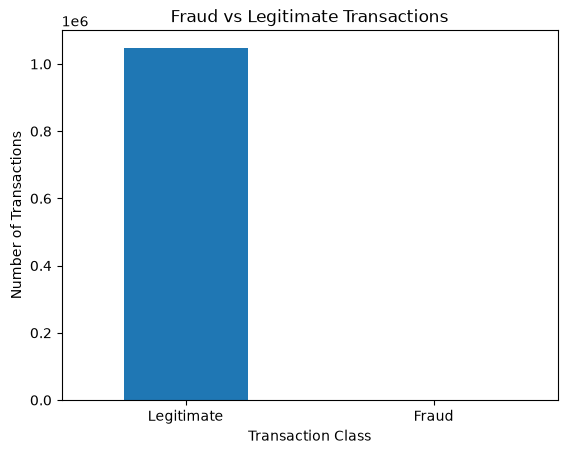

In [15]:
import matplotlib.pyplot as plt

df["isFraud"].value_counts().plot(kind="bar")

plt.title("Fraud vs Legitimate Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")
plt.xticks([0, 1], ["Legitimate", "Fraud"], rotation=0)
plt.show()

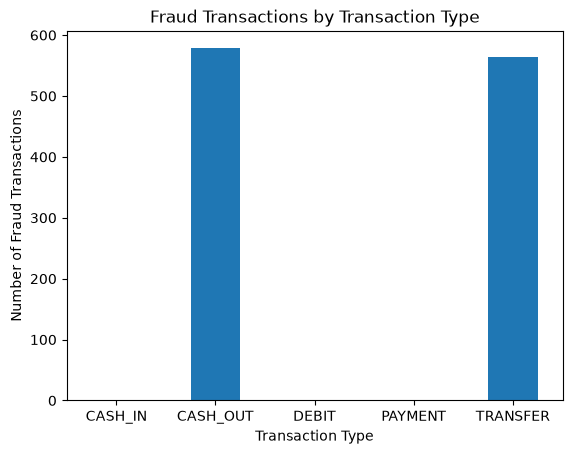

In [16]:
import matplotlib.pyplot as plt

fraud_by_type = df.groupby("type")["isFraud"].sum()

fraud_by_type.plot(kind="bar")

plt.title("Fraud Transactions by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Fraud Transactions")
plt.xticks(rotation=0)
plt.show()

In [17]:
fraud_rate = df.groupby("type")["isFraud"].mean() * 100

print(fraud_rate)

type
CASH_IN     0.000000
CASH_OUT    0.154694
DEBIT       0.000000
PAYMENT     0.000000
TRANSFER    0.650122
Name: isFraud, dtype: float64


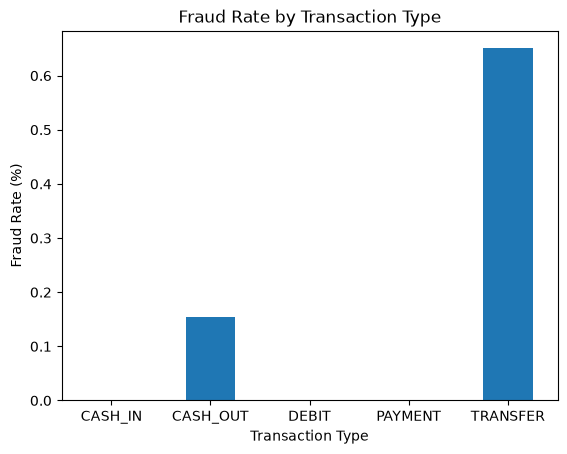

In [18]:
fraud_rate.plot(kind="bar")

plt.title("Fraud Rate by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [19]:
df.groupby("isFraud")["amount"].mean()

isFraud
0    1.575397e+05
1    1.192629e+06
Name: amount, dtype: float64

In [20]:
df.groupby("isFraud")["amount"].median()

isFraud
0     76214.97
1    353179.45
Name: amount, dtype: float64

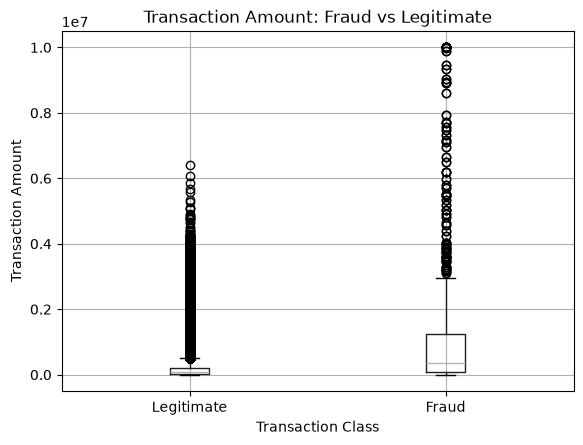

In [21]:
import matplotlib.pyplot as plt

df.boxplot(column="amount", by="isFraud")

plt.title("Transaction Amount: Fraud vs Legitimate")
plt.suptitle("")
plt.xlabel("Transaction Class")
plt.ylabel("Transaction Amount")
plt.xticks([1, 2], ["Legitimate", "Fraud"])
plt.show()

In [22]:
df.groupby("isFraud")[["oldbalanceOrg", "newbalanceOrig"]].mean()

,oldbalanceOrg,newbalanceOrig
isFraud,,
0,8.736338e+05,894746.395080
1,1.218636e+06,33944.321208


In [23]:
df.groupby("isFraud")[["oldbalanceDest", "newbalanceDest"]].mean()

,oldbalanceDest,newbalanceDest
isFraud,,
0,978732.769117,1.114237e+06
1,452866.124527,1.077940e+06


In [24]:
df.groupby("type")["isFraud"].agg(["count", "sum", "mean"])

,count,sum,mean
type,,,
CASH_IN,227130,0,0.000000
CASH_OUT,373641,578,0.001547
DEBIT,7178,0,0.000000
PAYMENT,353873,0,0.000000
TRANSFER,86753,564,0.006501


In [25]:
df["isFlaggedFraud"].value_counts()

isFlaggedFraud
0    1048575
Name: count, dtype: int64

In [26]:
df.groupby("step")["isFraud"].sum().sort_values(ascending=False).head(10)

step
66    24
22    23
6     22
34    22
74    22
47    21
15    20
58    20
59    20
71    20
Name: isFraud, dtype: int64

In [27]:
df.groupby("step")["isFraud"].mean().sort_values(ascending=False).head(10)

step
30    1.0
29    1.0
28    1.0
31    1.0
69    1.0
70    1.0
71    1.0
72    1.0
73    1.0
74    1.0
Name: isFraud, dtype: float64

In [28]:
df.groupby("step")["isFraud"].agg(["count", "sum", "mean"]).sort_values("mean", ascending=False).head(15)

,count,sum,mean
step,,,
30,8,8,1.0
29,4,4,1.0
28,4,4,1.0
31,12,12,1.0
69,20,20,1.0
70,6,6,1.0
71,20,20,1.0
72,14,14,1.0
73,8,8,1.0


In [29]:
df_clean = df.copy()

In [30]:
df_clean.shape

(1048575, 11)

In [31]:
df_clean.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [32]:
df_clean.duplicated().sum()

np.int64(0)

In [33]:
df_clean[[
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest"
]].min()

amount            0.1
oldbalanceOrg     0.0
newbalanceOrig    0.0
oldbalanceDest    0.0
newbalanceDest    0.0
dtype: float64

In [34]:
df_clean.dtypes

step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

In [35]:
df_clean[["type", "nameOrig", "nameDest"]].nunique()

type              5
nameOrig    1048317
nameDest     449635
dtype: int64

In [36]:
df_clean["isFlaggedFraud"].value_counts()

isFlaggedFraud
0    1048575
Name: count, dtype: int64

In [37]:
df_clean = df_clean.drop(columns=["isFlaggedFraud"])

In [38]:
df_clean.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud'],
      dtype='object')

In [39]:
df_clean["balance_diff_orig"] = (
    df_clean["oldbalanceOrg"]
    - df_clean["amount"]
    - df_clean["newbalanceOrig"]
)

df_clean["balance_diff_dest"] = (
    df_clean["oldbalanceDest"]
    + df_clean["amount"]
    - df_clean["newbalanceDest"]
)

In [40]:
df_clean[["balance_diff_orig", "balance_diff_dest"]].describe()

,balance_diff_orig,balance_diff_dest
count,1.048575e+06,1.048575e+06
mean,-1.784663e+05,2.262906e+04
std,2.812392e+05,4.326599e+05
min,-6.388051e+06,-3.509592e+07
25%,-2.508190e+05,0.000000e+00
50%,-6.748822e+04,4.413380e+03
75%,-1.517990e+03,3.218935e+04
max,8.802473e+04,1.323041e+07


In [41]:
df_clean.groupby("isFraud")[[
    "balance_diff_orig",
    "balance_diff_dest"
]].mean()

,balance_diff_orig,balance_diff_dest
isFraud,,
0,-178652.254665,22034.932456
1,-7937.031935,567554.586025


In [42]:
df_clean[[
    "balance_diff_orig",
    "balance_diff_dest"
]].quantile([0.01, 0.05, 0.50, 0.95, 0.99])


,balance_diff_orig,balance_diff_dest
0.01,-1.294302e+06,-1.183462e+06
0.05,-6.854398e+05,-2.785085e+05
0.50,-6.748822e+04,4.413380e+03
0.95,0.000000e+00,4.611076e+05
0.99,1.000000e-02,8.200489e+05


In [43]:
df_clean.groupby("isFraud")["amount"].quantile(
    [0.25, 0.50, 0.75, 0.95, 0.99]
)

isFraud      
0        0.25    1.213487e+04
         0.50    7.621497e+04
         0.75    2.134928e+05
         0.95    5.174136e+05
         0.99    1.295184e+06
1        0.25    8.607017e+04
         0.50    3.531794e+05
         0.75    1.248759e+06
         0.95    5.970628e+06
         0.99    1.000000e+07
Name: amount, dtype: float64

In [44]:
df_clean.groupby("nameOrig").size().describe()

count    1.048317e+06
mean     1.000246e+00
std      1.568593e-02
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      2.000000e+00
dtype: float64

In [45]:
df_clean.groupby("nameDest").size().describe()

count    449635.000000
mean          2.332058
std           4.267986
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          98.000000
dtype: float64

In [46]:
df_clean["dest_transaction_count"] = (
    df_clean.groupby("nameDest")["nameDest"].transform("count")
)

In [47]:
df_clean["dest_transaction_count"].describe()

count    1.048575e+06
mean     1.014304e+01
std      1.081459e+01
min      1.000000e+00
25%      1.000000e+00
50%      7.000000e+00
75%      1.600000e+01
max      9.800000e+01
Name: dest_transaction_count, dtype: float64

In [48]:
df_clean.groupby("isFraud")["dest_transaction_count"].mean()

isFraud
0    10.145925
1     7.495622
Name: dest_transaction_count, dtype: float64

In [49]:
df_clean.groupby("type")["isFraud"].agg(
    ["count", "sum", "mean"]
)

,count,sum,mean
type,,,
CASH_IN,227130,0,0.000000
CASH_OUT,373641,578,0.001547
DEBIT,7178,0,0.000000
PAYMENT,353873,0,0.000000
TRANSFER,86753,564,0.006501


In [50]:
df_clean["isFraud"].value_counts(normalize=True) * 100

isFraud
0    99.89109
1     0.10891
Name: proportion, dtype: float64

In [51]:
X = df_clean.drop(columns=["isFraud"])
y = df_clean["isFraud"]

In [52]:
X.shape, y.shape

((1048575, 12), (1048575,))

In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [54]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((838860, 12), (209715, 12), (838860,), (209715,))

In [55]:
print("Training:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting:")
print(y_test.value_counts(normalize=True) * 100)

Training:
isFraud
0    99.891043
1     0.108957
Name: proportion, dtype: float64

Testing:
isFraud
0    99.891281
1     0.108719
Name: proportion, dtype: float64


In [56]:
# Calculate destination transaction counts using training data only
dest_counts_train = X_train["nameDest"].value_counts()

# Recalculate the feature safely
X_train["dest_transaction_count"] = (
    X_train["nameDest"].map(dest_counts_train)
)

X_test["dest_transaction_count"] = (
    X_test["nameDest"].map(dest_counts_train).fillna(0)
)

In [57]:
print(X_train["dest_transaction_count"].describe())
print(X_test["dest_transaction_count"].describe())

count    838860.000000
mean          8.322540
std           8.718627
min           1.000000
25%           1.000000
50%           5.000000
75%          13.000000
max          77.000000
Name: dest_transaction_count, dtype: float64
count    209715.000000
mean          7.297222
std           8.746064
min           0.000000
25%           0.000000
50%           4.000000
75%          12.000000
max          77.000000
Name: dest_transaction_count, dtype: float64


In [58]:
X_train = X_train.drop(columns=["nameOrig", "nameDest"])
X_test = X_test.drop(columns=["nameOrig", "nameDest"])

In [59]:
print(X_train.columns)
print(X_train.shape)
print(X_test.shape)

Index(['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
       'oldbalanceDest', 'newbalanceDest', 'balance_diff_orig',
       'balance_diff_dest', 'dest_transaction_count'],
      dtype='object')
(838860, 10)
(209715, 10)


In [60]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

type_train = encoder.fit_transform(X_train[["type"]])
type_test = encoder.transform(X_test[["type"]])

In [61]:
print(encoder.get_feature_names_out(["type"]))
print(type_train.shape)
print(type_test.shape)

['type_CASH_IN' 'type_CASH_OUT' 'type_DEBIT' 'type_PAYMENT'
 'type_TRANSFER']
(838860, 5)
(209715, 5)


In [62]:
X_train_num = X_train.drop(columns=["type"])
X_test_num = X_test.drop(columns=["type"])

In [63]:
import pandas as pd

type_train_df = pd.DataFrame(
    type_train,
    columns=encoder.get_feature_names_out(["type"]),
    index=X_train.index
)

type_test_df = pd.DataFrame(
    type_test,
    columns=encoder.get_feature_names_out(["type"]),
    index=X_test.index
)

In [64]:
X_train_final = pd.concat([X_train_num, type_train_df], axis=1)
X_test_final = pd.concat([X_test_num, type_test_df], axis=1)

In [65]:
print(X_train_final.shape)
print(X_test_final.shape)
print(X_train_final.columns)

(838860, 14)
(209715, 14)
Index(['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest',
       'newbalanceDest', 'balance_diff_orig', 'balance_diff_dest',
       'dest_transaction_count', 'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT',
       'type_PAYMENT', 'type_TRANSFER'],
      dtype='object')


In [66]:
print(y_train.value_counts())
print(y_test.value_counts())

print("\nTraining fraud percentage:")
print(y_train.mean() * 100)

print("\nTesting fraud percentage:")
print(y_test.mean() * 100)

isFraud
0    837946
1       914
Name: count, dtype: int64
isFraud
0    209487
1       228
Name: count, dtype: int64

Training fraud percentage:
0.10895739455928284

Testing fraud percentage:
0.10871897575280738


In [67]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train_final, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [68]:
y_pred = log_model.predict(X_test_final)

print(y_pred[:20])

[0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [69]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

y_prob = log_model.predict_proba(X_test_final)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("PR-AUC:", average_precision_score(y_test, y_prob))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98    209487
           1       0.02      0.91      0.05       228

    accuracy                           0.96    209715
   macro avg       0.51      0.94      0.51    209715
weighted avg       1.00      0.96      0.98    209715

Confusion Matrix:
[[200750   8737]
 [    20    208]]
ROC-AUC: 0.9799566970575322
PR-AUC: 0.4420823892278846


In [70]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]

for threshold in thresholds:
    y_threshold = (y_prob >= threshold).astype(int)

    precision = precision_score(y_test, y_threshold, zero_division=0)
    recall = recall_score(y_test, y_threshold)
    f1 = f1_score(y_test, y_threshold)

    print(
        f"Threshold: {threshold} | "
        f"Precision: {precision:.4f} | "
        f"Recall: {recall:.4f} | "
        f"F1: {f1:.4f}"
    )

Threshold: 0.1 | Precision: 0.0045 | Recall: 0.9781 | F1: 0.0090
Threshold: 0.2 | Precision: 0.0072 | Recall: 0.9781 | F1: 0.0144
Threshold: 0.3 | Precision: 0.0111 | Recall: 0.9605 | F1: 0.0219
Threshold: 0.4 | Precision: 0.0167 | Recall: 0.9518 | F1: 0.0328
Threshold: 0.5 | Precision: 0.0233 | Recall: 0.9123 | F1: 0.0454


In [71]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_final, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

In [72]:
rf_pred = rf_model.predict(X_test_final)

print(rf_pred[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [73]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

print("Classification Report:")
print(classification_report(y_test, rf_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

rf_prob = rf_model.predict_proba(X_test_final)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, rf_prob))
print("PR-AUC:", average_precision_score(y_test, rf_prob))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    209487
           1       1.00      0.98      0.99       228

    accuracy                           1.00    209715
   macro avg       1.00      0.99      0.99    209715
weighted avg       1.00      1.00      1.00    209715

Confusion Matrix:
[[209487      0]
 [     5    223]]
ROC-AUC: 0.9911642132631602
PR-AUC: 0.9788022069549802


In [74]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train_final.columns
).sort_values(ascending=False)

print(feature_importance)

balance_diff_orig         0.353553
newbalanceOrig            0.147150
step                      0.103767
oldbalanceOrg             0.083793
amount                    0.060349
type_PAYMENT              0.059451
type_TRANSFER             0.056029
oldbalanceDest            0.031348
type_CASH_OUT             0.027749
balance_diff_dest         0.026510
newbalanceDest            0.025219
dest_transaction_count    0.014123
type_CASH_IN              0.009981
type_DEBIT                0.000979
dtype: float64


In [75]:
X_train_no_diff = X_train_final.drop(columns=["balance_diff_orig"])
X_test_no_diff = X_test_final.drop(columns=["balance_diff_orig"])

rf_no_diff = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_no_diff.fit(X_train_no_diff, y_train)

y_pred_no_diff = rf_no_diff.predict(X_test_no_diff)
y_prob_no_diff = rf_no_diff.predict_proba(X_test_no_diff)[:, 1]

In [76]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

print(classification_report(y_test, y_pred_no_diff))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_no_diff))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_no_diff))
print("PR-AUC:", average_precision_score(y_test, y_prob_no_diff))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    209487
           1       0.98      0.75      0.85       228

    accuracy                           1.00    209715
   macro avg       0.99      0.87      0.92    209715
weighted avg       1.00      1.00      1.00    209715

Confusion Matrix:
[[209483      4]
 [    57    171]]
ROC-AUC: 0.9817504167867386
PR-AUC: 0.869417032281435


In [77]:
feature_importance_no_diff = pd.Series(
    rf_no_diff.feature_importances_,
    index=X_train_no_diff.columns
).sort_values(ascending=False)

print(feature_importance_no_diff)

oldbalanceOrg             0.205846
step                      0.161558
newbalanceOrig            0.127410
amount                    0.126902
type_TRANSFER             0.068703
type_PAYMENT              0.064911
oldbalanceDest            0.057931
newbalanceDest            0.050585
type_CASH_OUT             0.040714
balance_diff_dest         0.040591
type_CASH_IN              0.033094
dest_transaction_count    0.021184
type_DEBIT                0.000571
dtype: float64


In [78]:
fraud_by_step = df.groupby("step")["isFraud"].agg(
    ["count", "sum", "mean"]
)

fraud_by_step.columns = [
    "total_transactions",
    "fraud_count",
    "fraud_rate"
]

print(fraud_by_step.sort_values("fraud_rate", ascending=False).head(10))

      total_transactions  fraud_count  fraud_rate
step                                             
30                     8            8         1.0
29                     4            4         1.0
28                     4            4         1.0
31                    12           12         1.0
69                    20           20         1.0
70                     6            6         1.0
71                    20           20         1.0
72                    14           14         1.0
73                     8            8         1.0
74                    22           22         1.0


In [79]:
step_analysis = df.groupby("step")["isFraud"].agg(
    total_transactions="count",
    fraud_count="sum"
)

step_analysis["fraud_rate"] = (
    step_analysis["fraud_count"] /
    step_analysis["total_transactions"]
)

print(
    step_analysis[
        step_analysis["total_transactions"] >= 1000
    ].sort_values("fraud_rate", ascending=False).head(15)
)

      total_transactions  fraud_count  fraud_rate
step                                             
6                   1660           22    0.013253
25                  1598           18    0.011264
2                   1014            8    0.007890
1                   2708           16    0.005908
93                  4444           16    0.003600
95                  2980            8    0.002685
47                  8681           21    0.002419
24                  3216            6    0.001866
22                 12635           23    0.001820
48                  5693           10    0.001757
7                   6837           12    0.001755
94                 10372           12    0.001157
46                 12445           14    0.001125
45                 18500           16    0.000865
34                 30904           22    0.000712


In [80]:
print(df["step"].min())
print(df["step"].max())

1
95


In [81]:
step_counts = df.groupby("step")["isFraud"].agg(
    total_transactions="count",
    fraud_count="sum"
)

print(step_counts)

      total_transactions  fraud_count
step                                 
1                   2708           16
2                   1014            8
3                    552            4
4                    565           10
5                    665            6
...                  ...          ...
91                     8            8
92                    10           10
93                  4444           16
94                 10372           12
95                  2980            8

[95 rows x 2 columns]


In [82]:
future_data = df[df["step"] >= 76]

print("Shape:", future_data.shape)
print("\nFraud distribution:")
print(future_data["isFraud"].value_counts())

print("\nFraud rate:")
print(future_data["isFraud"].mean())

Shape: (17974, 11)

Fraud distribution:
isFraud
0    17760
1      214
Name: count, dtype: int64

Fraud rate:
0.011906086569489263


In [83]:
# Step 1 — Create time-based train/test data

time_train = df_clean[df_clean["step"] < 76].copy()
time_test = df_clean[df_clean["step"] >= 76].copy()

print("Time Train shape:", time_train.shape)
print("Time Test shape:", time_test.shape)

print("\nTrain fraud:")
print(time_train["isFraud"].value_counts())

print("\nTest fraud:")
print(time_test["isFraud"].value_counts())

Time Train shape: (1030601, 13)
Time Test shape: (17974, 13)

Train fraud:
isFraud
0    1029673
1        928
Name: count, dtype: int64

Test fraud:
isFraud
0    17760
1      214
Name: count, dtype: int64


In [84]:
# Step 2 — Separate X and y

X_time_train = time_train.drop(columns=["isFraud"])
y_time_train = time_train["isFraud"]

X_time_test = time_test.drop(columns=["isFraud"])
y_time_test = time_test["isFraud"]

In [85]:
# Step 3 — Remove raw account IDs

X_time_train = X_time_train.drop(columns=["nameOrig"])
X_time_test = X_time_test.drop(columns=["nameOrig"])

In [86]:
# Step 4 — Create balance-difference features

X_time_train["balance_diff_orig"] = (
    X_time_train["oldbalanceOrg"]
    - X_time_train["amount"]
    - X_time_train["newbalanceOrig"]
)

X_time_test["balance_diff_orig"] = (
    X_time_test["oldbalanceOrg"]
    - X_time_test["amount"]
    - X_time_test["newbalanceOrig"]
)

X_time_train["balance_diff_dest"] = (
    X_time_train["oldbalanceDest"]
    + X_time_train["amount"]
    - X_time_train["newbalanceDest"]
)

X_time_test["balance_diff_dest"] = (
    X_time_test["oldbalanceDest"]
    + X_time_test["amount"]
    - X_time_test["newbalanceDest"]
)

In [87]:
# Step 5 — Create leakage-safe destination counts

# Important: fit the counts only on the training period.

dest_counts_time = X_time_train["nameDest"].value_counts()

X_time_train["dest_transaction_count"] = (
    X_time_train["nameDest"].map(dest_counts_time)
)

X_time_test["dest_transaction_count"] = (
    X_time_test["nameDest"].map(dest_counts_time).fillna(0)
)

In [88]:
# Now remove the IDs:

X_time_train = X_time_train.drop(columns=["nameDest"])
X_time_test = X_time_test.drop(columns=["nameDest"])

In [89]:
# Step 6 — One-hot encode type

from sklearn.preprocessing import OneHotEncoder

time_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

type_time_train = time_encoder.fit_transform(
    X_time_train[["type"]]
)

type_time_test = time_encoder.transform(
    X_time_test[["type"]]
)

In [90]:
# Then:

X_time_train_num = X_time_train.drop(columns=["type"])
X_time_test_num = X_time_test.drop(columns=["type"])

type_time_train_df = pd.DataFrame(
    type_time_train,
    columns=time_encoder.get_feature_names_out(["type"]),
    index=X_time_train.index
)

type_time_test_df = pd.DataFrame(
    type_time_test,
    columns=time_encoder.get_feature_names_out(["type"]),
    index=X_time_test.index
)

X_time_train_final = pd.concat(
    [X_time_train_num, type_time_train_df],
    axis=1
)

X_time_test_final = pd.concat(
    [X_time_test_num, type_time_test_df],
    axis=1
)

In [91]:
# Step 7 — Train Random Forest

rf_time = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_time.fit(X_time_train_final, y_time_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

In [92]:
# Then predict:

y_time_pred = rf_time.predict(X_time_test_final)
y_time_prob = rf_time.predict_proba(X_time_test_final)[:, 1]

In [93]:
# Finally:

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

print(classification_report(y_time_test, y_time_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_time_test, y_time_pred))

print("ROC-AUC:", roc_auc_score(y_time_test, y_time_prob))
print("PR-AUC:", average_precision_score(y_time_test, y_time_prob))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     17760
           1       1.00      1.00      1.00       214

    accuracy                           1.00     17974
   macro avg       1.00      1.00      1.00     17974
weighted avg       1.00      1.00      1.00     17974

Confusion Matrix:
[[17759     1]
 [    0   214]]
ROC-AUC: 1.0
PR-AUC: 1.0


In [94]:
# Create:

X_time_train_no_step = X_time_train_final.drop(columns=["step"])
X_time_test_no_step = X_time_test_final.drop(columns=["step"])

In [95]:
# Then train:

rf_time_no_step = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_time_no_step.fit(X_time_train_no_step, y_time_train)

y_pred_no_step = rf_time_no_step.predict(X_time_test_no_step)
y_prob_no_step = rf_time_no_step.predict_proba(
    X_time_test_no_step
)[:, 1]

In [96]:
# Evaluate:

print(classification_report(y_time_test, y_pred_no_step))

print("Confusion Matrix:")
print(confusion_matrix(y_time_test, y_pred_no_step))

print("ROC-AUC:", roc_auc_score(y_time_test, y_prob_no_step))
print("PR-AUC:", average_precision_score(y_time_test, y_prob_no_step))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     17760
           1       1.00      1.00      1.00       214

    accuracy                           1.00     17974
   macro avg       1.00      1.00      1.00     17974
weighted avg       1.00      1.00      1.00     17974

Confusion Matrix:
[[17760     0]
 [    0   214]]
ROC-AUC: 1.0
PR-AUC: 1.0


In [97]:
# Next experiment: remove BOTH engineered balance features

# Create:

X_time_train_no_balance = X_time_train_final.drop(
    columns=["balance_diff_orig", "balance_diff_dest", "step"]
)

X_time_test_no_balance = X_time_test_final.drop(
    columns=["balance_diff_orig", "balance_diff_dest", "step"]
)

In [98]:
# Then train:

rf_time_no_balance = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_time_no_balance.fit(
    X_time_train_no_balance,
    y_time_train
)

y_pred_no_balance = rf_time_no_balance.predict(
    X_time_test_no_balance
)

y_prob_no_balance = rf_time_no_balance.predict_proba(
    X_time_test_no_balance
)[:, 1]

In [99]:
# Evaluate:

print(classification_report(y_time_test, y_pred_no_balance))

print("Confusion Matrix:")
print(confusion_matrix(y_time_test, y_pred_no_balance))

print("ROC-AUC:",
      roc_auc_score(y_time_test, y_prob_no_balance))

print("PR-AUC:",
      average_precision_score(y_time_test, y_prob_no_balance))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     17760
           1       0.99      0.75      0.85       214

    accuracy                           1.00     17974
   macro avg       1.00      0.87      0.93     17974
weighted avg       1.00      1.00      1.00     17974

Confusion Matrix:
[[17759     1]
 [   54   160]]
ROC-AUC: 0.992692809632062
PR-AUC: 0.9668780378683617


In [100]:
from xgboost import XGBClassifier

In [101]:
# Step 3 — Train XGBoost

# For our first experiment, use the full time-based feature set (X_time_train_final and X_time_test_final):

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

xgb_model.fit(
    X_time_train_final,
    y_time_train
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [102]:
# Step 4 — Predictions

y_pred_xgb = xgb_model.predict(X_time_test_final)

y_prob_xgb = xgb_model.predict_proba(
    X_time_test_final
)[:, 1]

In [103]:
# Step 5 — Evaluation

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

print(classification_report(y_time_test, y_pred_xgb))

print("Confusion Matrix:")
print(confusion_matrix(y_time_test, y_pred_xgb))

print("ROC-AUC:", roc_auc_score(y_time_test, y_prob_xgb))

print("PR-AUC:", average_precision_score(y_time_test, y_prob_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     17760
           1       0.98      1.00      0.99       214

    accuracy                           1.00     17974
   macro avg       0.99      1.00      1.00     17974
weighted avg       1.00      1.00      1.00     17974

Confusion Matrix:
[[17756     4]
 [    0   214]]
ROC-AUC: 1.0000000000000002
PR-AUC: 1.0


In [104]:
# Next step: XGBoost feature importance

# Before tuning XGBoost, let's understand what features it is using.

xgb_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X_time_train_final.columns
).sort_values(ascending=False)

print(xgb_importance)

type_PAYMENT              0.319568
type_TRANSFER             0.254402
step                      0.140673
newbalanceOrig            0.121168
amount                    0.062785
type_CASH_IN              0.030308
balance_diff_orig         0.029157
type_CASH_OUT             0.017713
oldbalanceOrg             0.011000
newbalanceDest            0.005367
balance_diff_dest         0.003953
oldbalanceDest            0.002438
dest_transaction_count    0.001469
type_DEBIT                0.000000
dtype: float32


In [105]:
# We'll start with RandomizedSearchCV, because the dataset is large and searching every possible combination with GridSearchCV would be expensive.

from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0]
}

xgb_base = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=10,
    scoring="average_precision",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(
    X_time_train_final,
    y_time_train
)

print("Best Parameters:")
print(random_search.best_params_)

print("Best CV PR-AUC:")
print(random_search.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters:
{'subsample': 0.7, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
Best CV PR-AUC:
0.9721222945411129


In [106]:
# Next step: Evaluate the tuned model

# Now we need to see how these parameters perform on our unseen time-based test set.

best_xgb = random_search.best_estimator_

y_pred_best_xgb = best_xgb.predict(X_time_test_final)

y_prob_best_xgb = best_xgb.predict_proba(
    X_time_test_final
)[:, 1]

In [107]:
# Then:

print(classification_report(
    y_time_test,
    y_pred_best_xgb
))

print("Confusion Matrix:")
print(confusion_matrix(
    y_time_test,
    y_pred_best_xgb
))

print("ROC-AUC:",
      roc_auc_score(
          y_time_test,
          y_prob_best_xgb
      ))

print("PR-AUC:",
      average_precision_score(
          y_time_test,
          y_prob_best_xgb
      ))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     17760
           1       1.00      0.99      1.00       214

    accuracy                           1.00     17974
   macro avg       1.00      1.00      1.00     17974
weighted avg       1.00      1.00      1.00     17974

Confusion Matrix:
[[17760     0]
 [    2   212]]
ROC-AUC: 1.0
PR-AUC: 1.0


In [108]:
# Step 2 — Import SHAP

import shap
import matplotlib.pyplot as plt

In [109]:
# Step 3 — Create SHAP Explainer

# Use our tuned XGBoost model:

explainer = shap.TreeExplainer(best_xgb)

In [110]:
# Then calculate SHAP values on a sample of the test data. Since the test set has many rows, we'll use 5,000 rows to keep it faster:

X_shap = X_time_test_final.sample(
    n=min(5000, len(X_time_test_final)),
    random_state=42
)

shap_values = explainer.shap_values(X_shap)

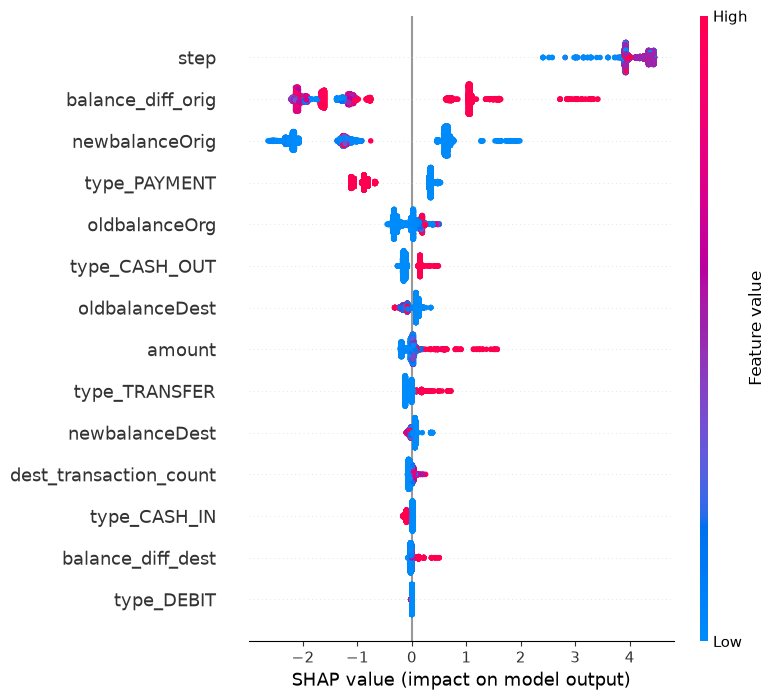

In [111]:
# Step 4 — SHAP Summary Plot

shap.summary_plot(
    shap_values,
    X_shap
)

In [112]:
# Next Step: Individual Fraud Explanation

# Now we'll take one transaction that XGBoost predicted as fraud and use SHAP to answer:

# "Why did FraudShield flag this particular transaction?"

# Find transactions predicted as fraud
fraud_indices = X_time_test_final.index[
    y_pred_best_xgb == 1
]

print("Number of predicted fraud transactions:",
      len(fraud_indices))

print("First fraud index:",
      fraud_indices[0])

Number of predicted fraud transactions: 212
First fraud index: 1030601


In [113]:
# Then:

# Select one predicted fraud transaction
fraud_index = fraud_indices[0]

X_one = X_time_test_final.loc[[fraud_index]]

print(X_one)

         step   amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  \
1030601    76  9917.27        9917.27             0.0             0.0   

         newbalanceDest  balance_diff_orig  balance_diff_dest  \
1030601             0.0                0.0            9917.27   

         dest_transaction_count  type_CASH_IN  type_CASH_OUT  type_DEBIT  \
1030601                     0.0           0.0            0.0         0.0   

         type_PAYMENT  type_TRANSFER  
1030601           0.0            1.0  


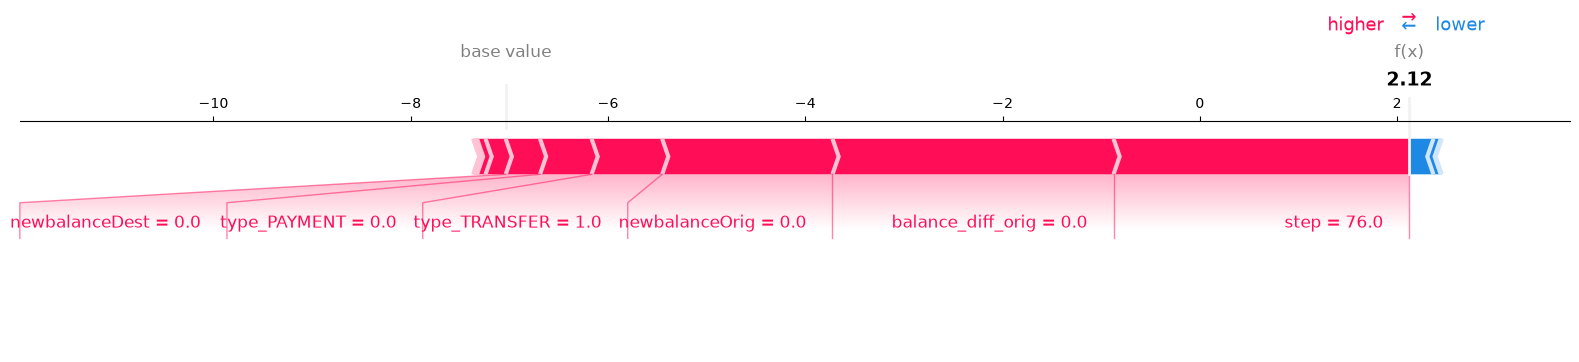

In [114]:
# Then calculate its SHAP values:

shap_one = explainer.shap_values(X_one)

shap.force_plot(
    explainer.expected_value,
    shap_one[0],
    X_one.iloc[0],
    matplotlib=True
)

In [115]:
# We cannot yet say exactly which feature caused XGBoost to flag it just from this table.

# For that, we need the actual SHAP values for this transaction.

shap_one = explainer.shap_values(X_one)

shap_contribution = pd.Series(
    shap_one[0],
    index=X_one.columns
).sort_values(key=abs, ascending=False)

print(shap_contribution)

step                      2.999255
balance_diff_orig         2.848855
newbalanceOrig            1.726601
type_TRANSFER             0.715504
type_PAYMENT              0.522868
newbalanceDest            0.347908
type_CASH_OUT            -0.243758
oldbalanceDest            0.204252
oldbalanceOrg             0.086419
dest_transaction_count   -0.074113
balance_diff_dest         0.020787
type_CASH_IN              0.016738
amount                   -0.010640
type_DEBIT                0.000301
dtype: float32


In [120]:
# Our next step is Model Saving. We should save the trained XGBoost model and the encoder so that later our Streamlit app can use the model without retraining it.

# Step 1 — Create the models folder automatically

# import os

# model_path = r"C:\Users\garvi\Downloads\FraudShield\models"

# os.makedirs(model_path, exist_ok=True)

# print("Models folder ready!")

In [118]:
import os

model_path = r"C:\Users\garvi\Downloads\FraudShield\models"

print("Exists:", os.path.exists(model_path))
print("Is folder:", os.path.isdir(model_path))
print("Is file:", os.path.isfile(model_path))

Exists: True
Is folder: False
Is file: True


In [119]:
import os

model_path = r"C:\Users\garvi\Downloads\FraudShield\models"

print("Exists:", os.path.exists(model_path))
print("Is folder:", os.path.isdir(model_path))
print("Is file:", os.path.isfile(model_path))

Exists: True
Is folder: False
Is file: True


In [ ]:
# Step 1 — Rename the existing models file

import os

old_path = r"C:\Users\garvi\Downloads\FraudShield\models"
new_path = r"C:\Users\garvi\Downloads\FraudShield\models_old"

os.rename(old_path, new_path)

print("Existing file renamed successfully!")

Existing file renamed successfully!


In [122]:
# Step 2 — Create the actual models folder

model_path = r"C:\Users\garvi\Downloads\FraudShield\models"

os.makedirs(model_path)

print("Models folder created successfully!")

Models folder created successfully!


In [123]:
# Step 3 — Save your tuned XGBoost model

import joblib

joblib.dump(
    best_xgb,
    r"C:\Users\garvi\Downloads\FraudShield\models\fraud_xgb_model.pkl"
)

print("XGBoost model saved successfully!")

XGBoost model saved successfully!


In [124]:
# Step 4 — Save the encoder

joblib.dump(
    encoder,
    r"C:\Users\garvi\Downloads\FraudShield\models\type_encoder.pkl"
)

print("Encoder saved successfully!")

Encoder saved successfully!


In [125]:
# Step 5 — Verify

print(os.path.isfile(
    r"C:\Users\garvi\Downloads\FraudShield\models\fraud_xgb_model.pkl"
))

print(os.path.isfile(
    r"C:\Users\garvi\Downloads\FraudShield\models\type_encoder.pkl"
))

True
True


In [126]:
# Step 1 — Load the saved model and encoder

import joblib

model = joblib.load(
    r"C:\Users\garvi\Downloads\FraudShield\models\fraud_xgb_model.pkl"
)

encoder = joblib.load(
    r"C:\Users\garvi\Downloads\FraudShield\models\type_encoder.pkl"
)

print("Model and encoder loaded successfully!")

Model and encoder loaded successfully!


In [127]:
# Step 2 — Create one sample transaction

# We'll use a transaction similar to the one we just explained with SHAP:

new_transaction = {
    "step": 76,
    "type": "TRANSFER",
    "amount": 9917.27,
    "oldbalanceOrg": 9917.27,
    "newbalanceOrig": 0.0,
    "oldbalanceDest": 0.0,
    "newbalanceDest": 0.0,
    "dest_transaction_count": 0.0
}

In [128]:
# Step 3 — Convert it into a DataFrame

import pandas as pd

new_df = pd.DataFrame([new_transaction])

print(new_df)

   step      type   amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  \
0    76  TRANSFER  9917.27        9917.27             0.0             0.0   

   newbalanceDest  dest_transaction_count  
0             0.0                     0.0  


In [129]:
# Step 4 — Create our engineered features

# Remember, the model was trained with these two features:

new_df["balance_diff_orig"] = (
    new_df["oldbalanceOrg"]
    - new_df["amount"]
    - new_df["newbalanceOrig"]
)

new_df["balance_diff_dest"] = (
    new_df["oldbalanceDest"]
    + new_df["amount"]
    - new_df["newbalanceDest"]
)

In [130]:
# Step 5 — Encode type

type_encoded = encoder.transform(
    new_df[["type"]]
)

type_encoded_df = pd.DataFrame(
    type_encoded,
    columns=encoder.get_feature_names_out(["type"])
)

In [131]:
# Step 6 — Create the final input

new_num = new_df.drop(columns=["type"])

new_final = pd.concat(
    [new_num.reset_index(drop=True),
     type_encoded_df.reset_index(drop=True)],
    axis=1
)

In [132]:
# Make sure the column order matches the training data:

new_final = new_final[
    X_time_train_final.columns
]

print(new_final)

   step   amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  \
0    76  9917.27        9917.27             0.0             0.0   

   newbalanceDest  balance_diff_orig  balance_diff_dest  \
0             0.0                0.0            9917.27   

   dest_transaction_count  type_CASH_IN  type_CASH_OUT  type_DEBIT  \
0                     0.0           0.0            0.0         0.0   

   type_PAYMENT  type_TRANSFER  
0           0.0            1.0  


In [133]:
# Step 7 — Predict 

prediction = model.predict(new_final)[0]

probability = model.predict_proba(
    new_final
)[0][1]

print("Prediction:", prediction)
print("Fraud Probability:", probability)

Prediction: 1
Fraud Probability: 0.8932275


In [134]:
# And finally:

if prediction == 1:
    print("🚨 FRAUD TRANSACTION")
else:
    print("✅ LEGITIMATE TRANSACTION")

🚨 FRAUD TRANSACTION


In [135]:
# Step 1 — Create the function

def predict_fraud(transaction):

    new_df = pd.DataFrame([transaction])

    # Create engineered features
    new_df["balance_diff_orig"] = (
        new_df["oldbalanceOrg"]
        - new_df["amount"]
        - new_df["newbalanceOrig"]
    )

    new_df["balance_diff_dest"] = (
        new_df["oldbalanceDest"]
        + new_df["amount"]
        - new_df["newbalanceDest"]
    )

    # Encode transaction type
    type_encoded = encoder.transform(
        new_df[["type"]]
    )

    type_encoded_df = pd.DataFrame(
        type_encoded,
        columns=encoder.get_feature_names_out(["type"])
    )

    # Remove original categorical column
    new_num = new_df.drop(columns=["type"])

    # Combine numerical + encoded features
    new_final = pd.concat(
        [
            new_num.reset_index(drop=True),
            type_encoded_df.reset_index(drop=True)
        ],
        axis=1
    )

    # Match training column order
    new_final = new_final[
        X_time_train_final.columns
    ]

    # Prediction
    prediction = model.predict(new_final)[0]

    probability = model.predict_proba(
        new_final
    )[0][1]

    return prediction, probability

In [136]:
# Step 2 — Test the function

prediction, probability = predict_fraud({
    "step": 76,
    "type": "TRANSFER",
    "amount": 9917.27,
    "oldbalanceOrg": 9917.27,
    "newbalanceOrig": 0.0,
    "oldbalanceDest": 0.0,
    "newbalanceDest": 0.0,
    "dest_transaction_count": 0.0
})

print("Prediction:", prediction)
print("Fraud Probability:", probability)

Prediction: 1
Fraud Probability: 0.8932275


In [138]:
# Recreate time-based split from original cleaned dataset

time_train = df_clean[df_clean["step"] < 76].copy()
time_test = df_clean[df_clean["step"] >= 76].copy()

X_time_train_raw = time_train.drop(columns=["isFraud"])
y_time_train = time_train["isFraud"]

X_time_test_raw = time_test.drop(columns=["isFraud"])
y_time_test = time_test["isFraud"]

print(X_time_train_raw.columns.tolist())

['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'balance_diff_orig', 'balance_diff_dest', 'dest_transaction_count']


In [139]:
dest_counts = X_time_train_raw["nameDest"].value_counts()

print(dest_counts.head())

nameDest
C985934102     96
C1286084959    96
C1590550415    88
C248609774     88
C665576141     87
Name: count, dtype: int64


In [140]:
# Then test the prediction function

# Use this corrected function:

def predict_fraud(transaction):

    new_df = pd.DataFrame([transaction])

    # Destination transaction count
    destination = new_df["nameDest"].iloc[0]
    new_df["dest_transaction_count"] = dest_counts.get(destination, 0)

    # Engineered features
    new_df["balance_diff_orig"] = (
        new_df["oldbalanceOrg"]
        - new_df["amount"]
        - new_df["newbalanceOrig"]
    )

    new_df["balance_diff_dest"] = (
        new_df["oldbalanceDest"]
        + new_df["amount"]
        - new_df["newbalanceDest"]
    )

    # Remove columns not used by model
    new_df = new_df.drop(
        columns=["nameOrig", "nameDest", "isFlaggedFraud"],
        errors="ignore"
    )

    # Encode type
    type_encoded = encoder.transform(new_df[["type"]])

    type_encoded_df = pd.DataFrame(
        type_encoded,
        columns=encoder.get_feature_names_out(["type"])
    )

    new_num = new_df.drop(columns=["type"])

    # Combine
    new_final = pd.concat(
        [
            new_num.reset_index(drop=True),
            type_encoded_df.reset_index(drop=True)
        ],
        axis=1
    )

    # Same order as training
    new_final = new_final[X_time_train_final.columns]

    # Prediction
    prediction = model.predict(new_final)[0]

    probability = model.predict_proba(new_final)[0][1]

    return prediction, probability

In [141]:
prediction, probability = predict_fraud({
    "step": 76,
    "type": "TRANSFER",
    "amount": 9917.27,
    "nameOrig": "C123456",
    "nameDest": "C987654",
    "oldbalanceOrg": 9917.27,
    "newbalanceOrig": 0.0,
    "oldbalanceDest": 0.0,
    "newbalanceDest": 0.0
})

print("Prediction:", prediction)
print("Fraud Probability:", probability)

Prediction: 1
Fraud Probability: 0.8932275
